## Comments

This factor model is based on the paper Shrinking the cross-section by Kozak, Nagel and Santosh.  

In [1]:
import pandas as pd
import numpy as np

from datetime import datetime
import matplotlib.pyplot as plt
#from utils_new import demarket, regcov, l2est
#from cross_validate import cross_validate


import os

os.chdir(r"C:\Users\ulsi")
print("Current directory:", os.getcwd())


Current directory: C:\Users\ulsi


## Utilities and cross validation

In [2]:

def demarket(r, mkt, b=None):
    """
    Demarket function to compute market beta and de-market returns.

    Parameters:
    - r: DataFrame or 2D array of returns.
    - mkt: Series or 1D array of market returns.
    - b: Optional; market beta. If not provided, it will be computed.

    Returns:
    - rme: DataFrame or 2D array of de-marketed returns.
    - b: market beta.
    """

    # If b (beta) is not provided, compute it
    if b is None:
        # Create a design matrix with intercept (column of ones) and market returns
        rhs = np.column_stack([np.ones(mkt.shape[0]), mkt])

        # Solve for beta using least squares
        b, _ = np.linalg.lstsq(rhs, r, rcond=None)[0:2]
        b = b[1:]

    # De-market
    rme = r - np.outer(mkt, b)

    return rme, b


def regcov(r):
    """
    Compute the regularized covariance matrix of r.

    Parameters:
    - r: Input data matrix

    Returns:
    - X: Regularized covariance matrix
    """
    
    # Compute covariance matrix
    X = np.cov(r, rowvar=False)

    # Covariance regularization (with flat Wishart prior)
    T, n = r.shape
    a = n / (n + T)
    X = a * np.trace(X) / n * np.eye(n) + (1 - a) * X

    return X


def l2est(X, y, params, compute_errors=False):
    l = params['L2pen']

    if compute_errors:
        Xinv = np.linalg.inv(X + l * np.eye(X.shape[0]))
        
        b = np.dot(Xinv, y)
        se = np.sqrt(1 / params['T'] * np.diag(Xinv))
    else:
        # Solve a system of linear equations instead if errors are not needed
        b = np.linalg.solve(X + l * np.eye(X.shape[0]), y)
        se = np.full(X.shape[0], np.nan)

    return b, params, se



def cross_validate(FUN, dates, r, params):
    """
    Compute IS/OOS values of the objective function based on the FUN function.
    Implements multiple objectives and validation methods.

    Parameters:
    - FUN: Handle to a function which estimates model parameters.
    - dates: (T x 1) array of dates.
    - r: (T x N) matrix of returns.
    - params: Dictionary that contains extra arguments.

    Returns:
    - obj: (1 x 2) IS and OOS values of the estimated objective function.
    - params: Returns back the params dictionary.
    - obj_folds: ...
    """
    if not callable(FUN):
        raise ValueError('Provided FUN argument is not a callable function.')

    # Select requested method
    if 'method' not in params:
        cross_validate_handler = cross_validate_cv_handler
    else:
        map_cv_method = {
            'CV': cross_validate_cv_handler,
            'ssplit': cross_validate_ssplit_handler,
            # 'bootstrap': cross_validate_bootstrap_handler
        }
        cross_validate_handler = map_cv_method.get(params['method'])

    # Execute selected method
    params['dd'] = dates
    params['ret'] = r
    params['fun'] = FUN
    obj, params, obj_folds = cross_validate_handler(params)

    return obj, params, obj_folds

def cross_validate_ssplit_handler(params):
    """
    Sample split handler for cross-validation.

    Parameters:
    - params: Dictionary with parameters, including 'splitdate', 'dd', etc.

    Returns:
    - obj, params: Results from the bootstrp_handler.
    """
    # Get split date or default to '01JAN2000'
    sd = params.get('splitdate', '01JAN2000')

    # Convert string date to datetime object
    tT0 = datetime.strptime(sd, '%d%b%Y')
    idx_test = [i for i, d in enumerate(params['dd']) if d >= tT0]

    return bootstrp_handler(idx_test, params)


def cross_validate_cv_handler(params):
    """
    Perform k-fold cross-validation.
    
    Parameters:
    - params: dictionary containing the parameters
    
    Returns:
    - obj: (k x 2) array of IS and OOS values of the estimated objective function for each fold
    - params: updated params dictionary
    - obj_folds: (k x 2) array, equal to obj
    
    Note: Requires custom function `bootstrp_handler` and `cvpartition_contiguous`.
    """
    
    # Set k (number of folds) either to provided value or default to 2
    k = params.get('kfold', 2)
    
    cv = cvpartition_contiguous(np.size(params['ret'],0), k)
    
    # Initialize obj to hold IS/OOS stats for each partition
    obj = np.nan * np.zeros((k, 2))
    
    for i in range(k):
        
        idx_test = cv[i]
        if 'cv_idx_test' not in params:
            params['cv_idx_test'] = {}
        params['cv_idx_test'][i] = idx_test
        params['cv_iteration'] = i
        obj[i, :], params = bootstrp_handler(idx_test, params)
        
    # Store estimates for each fold
    obj_folds = obj
    
    # Compute average and standard error of IS/OOS stats across folds
    obj = np.hstack([np.mean(obj, axis=0), np.std(obj, axis=0) / np.sqrt(k)])
    
    # Uncomment and modify the following code if 'SRexpl' objective function is used
    # if params['objective'] == 'SRexpl':
    #     obj = np.sqrt(np.maximum(0, obj))
    
    return obj, params, obj_folds

def bootstrp_handler(idx_test, params):
    
    if 'objective' in params:
        map_bootstrp_obj = {
            #'SSE': bootstrp_obj_SSE,
            #'GLS': bootstrp_obj_HJdist,
            'CSR2': bootstrp_obj_CSR2,
            #'GLSR2': bootstrp_obj_GLSR2,
            #'SRexpl': bootstrp_obj_SRexpl,
            #'SR': bootstrp_obj_SR,
            #'MVU': bootstrp_obj_MVutil
        }
        
        def_bootstrp_obj = map_bootstrp_obj[params['objective']]
    else:
        def_bootstrp_obj = bootstrp_obj_CSR2

    ret = params['ret']
    FUN = params['fun']

    n = ret.shape[0]
    idx = np.setdiff1d(np.arange(n), idx_test)  # difference between two arrays, providing training indices
    n_test = len(idx_test)

    invX = np.nan
    invX_test = np.nan
    res = [np.nan, np.nan]

    if n_test > 0:
        r = ret.iloc[idx, :]
        r_test = ret.iloc[idx_test, :]

        if 'cv_cache' not in params or len(params['cv_cache']) <= params['cv_iteration']:
            if 'cv_cache' not in params:
                params['cv_cache'] = {}
            cvdata = {}
            cvdata['X'] = regcov(r)
            cvdata['y'] = np.mean(r, axis=0)
            cvdata['X_test'] = regcov(r_test)
            cvdata['y_test'] = np.mean(r_test, axis=0)
            
            if params['objective'] in {'GLS', 'GLSR2', 'SRexpl'}:
                cvdata['invX'] = np.linalg.pinv(cvdata['X'])
                cvdata['invX_test'] = np.linalg.pinv(cvdata['X_test'])

            params['cv_cache'][params['cv_iteration']] = cvdata

        cvdata = params['cv_cache'][params['cv_iteration']]
        X = cvdata['X']
        y = cvdata['y']
        X_test = cvdata['X_test']
        y_test = cvdata['y_test']
        
        if params['objective'] in {'GLS', 'GLSR2', 'SRexpl'}:
            invX = cvdata['invX']
            invX_test = cvdata['invX_test']

        phi, params = FUN(X, y, params)[0:2]

        if 'cache_run' not in params or not params['cache_run']:
            if 'cv_phi' not in params:
                params['cv_phi'] = {}
            params['cv_phi'][params['cv_iteration']] = phi
            if 'cv_MVE' not in params:
                params['cv_MVE'] = {}
            params['cv_MVE'][params['cv_iteration']] = np.dot(r_test, phi)
            
            fact = np.dot(X, phi)
            fact_test = np.dot(X_test, phi)

            if params['ignore_scale']:
                b = np.linalg.lstsq(fact, y, rcond=None)[0]
                b_test = np.linalg.lstsq(fact_test, y_test, rcond=None)[0]
            else:
                b = 1
                b_test = 1

            res = [
                def_bootstrp_obj(np.dot(fact, b), y, invX, phi, r, params),
                def_bootstrp_obj(np.dot(fact_test, b_test), y_test, invX_test, phi, r_test, params)
            ]

    return np.hstack(res), params

def cvpartition_contiguous(n, k):
    """
    Create contiguous partitions for cross-validation.
    
    Parameters:
    - n: int, total number of data points
    - k: int, number of folds/partitions
    
    Returns:
    - indices: list of lists, containing indices for each fold
    """
    s = n // k  # using floor division to ensure integer result
    indices = [None] * k  # Pre-allocating list with k None elements
    
    for i in range(k - 1):
        # Using range indexing to create contiguous partitions
        indices[i] = list(range(s * i, s * (i + 1)))
    
    # Last partition takes the remaining elements
    indices[k - 1] = list(range(s * (k - 1), n))
    
    return indices

def bootstrp_obj_CSR2(y_hat, y, invX, phi, r, params):
    """
    Compute the objective based on the Coefficient of Squared Regression (CSR2).

    Parameters:
    - y_hat: Predicted values
    - y: Actual values
    - invX, phi, r, params: Other parameters that are not used in the computation
      in this function but are kept for consistency with other objective functions.
    
    Returns:
    - obj: The computed CSR2 objective value.
    """
    # Compute the CSR2 objective
    obj = 1 - (np.dot((y_hat - y).T, (y_hat - y))) / (np.dot(y.T, y))
    return obj

## Visuals

In [3]:
def plot_dof(df, x, p):
    """
    degrees of freedom <-> kappa plot
    
    Parameters:
    - df: Degrees of freedom data to be plotted on the y-axis.
    - x: Data to be plotted on the x-axis.
    - p: Dictionary containing various plot parameters.
    """
    
    # Open a new figure
    plt.figure()
    
    # Plot
    plt.plot(x, df, linewidth=p['line_width'])
    
    # Log-scale adjustments
    if p['L1_log_scale']:
        plt.yscale('log')
        plt.yticks([tick + 1e-12 for tick in plt.yticks()[0]])  # Adding a small constant
    
    if p['L2_log_scale']:
        plt.xscale('log')
        plt.xticks([tick + 1e-12 for tick in plt.xticks()[0]])  # Adding a small constant
    
    # Labels and grid
    plt.xlabel(p['xlbl'], fontsize=12, labelpad=10, fontweight='bold')
    plt.ylabel('Effective degrees of freedom', fontsize=12, labelpad=10, fontweight='bold')
    plt.grid(True)
    
    # Setting x-axis limits
    plt.xlim([min(x), max(x)])
    
    # Show plot
    if p['show_plot']:
        plt.show()

    if p['results_export']:
        plt.savefig('results_export/degrees_of_freedom.png', dpi=300, bbox_inches='tight')


def plot_L2coefpaths(x, phi, iL2opt, anomalies, ylbl, p):
    """
    L2 coefficients paths plot
    
    Parameters:
    - x: Data for the x-axis.
    - phi: Coefficient path data.
    - iL2opt: Optimal index for regularization.
    - anomalies: Names for legends.
    - ylbl: Label for the y-axis.
    - p: Dictionary containing various plot parameters.
    """
    
    # Decide sorting location
    if p['L2_sort_loc'] == 'opt':
        iSortLoc = iL2opt
    elif p['L2_sort_loc'] == 'OLS':
        iSortLoc = 0
    else:
        raise ValueError('Unknown option')
    
    # Sorting mechanism
    if p['n'] > p['L2_max_legends']:
        I = np.argsort(-np.abs(phi[:, iSortLoc]))  # Descending sort by absolute value
    else:
        I = np.argsort(-phi[:, iSortLoc])  # Descending sort
    
    # Open a new figure
    plt.figure()
    
    # Plot
    for i in I:
        plt.plot(x, phi[i, :], linewidth=p['line_width'])
    
    # Log-scale adjustment
    if p['L2_log_scale']:
        plt.xscale('log')
        plt.xticks([tick + 1e-16 for tick in plt.xticks()[0]])
    
    # Labels and grid
    plt.xlabel(p['xlbl'], fontsize=12, labelpad=10, fontweight='bold')
    plt.ylabel(ylbl, fontsize=12, labelpad=10, fontweight='bold')
    plt.grid(True)
    
    # Legend
    idx = I[:min(p['L2_max_legends'], len(I))]
    plt.legend([anomalies[i] for i in idx], loc=p['legend_loc'], fontsize=p['font_size'], bbox_to_anchor=(1.05, 1))
    
    # Dashed line at optimal regularization
    plt.plot([x[iL2opt], x[iL2opt]], [np.min(phi), np.max(phi)], '--k')
    
    # x-axis limits
    plt.xlim([min(x), max(x)])
    
    # Show plot
    if p['show_plot']:
        plt.show()

    if p['results_export']:
        if ylbl == 'SDF Coefficient, $b$':
            plt.savefig('results_export/coefficients_paths.png', dpi=300, bbox_inches='tight')
        elif ylbl == 'SDF Coefficient $t$-statistic':
            plt.savefig('results_export/tstats_paths.png', dpi=300, bbox_inches='tight')


def plot_L2cv(x, objL2, p):
    """
    Plot SSE/objective & BIC as a function of degrees of freedom.
    
    Parameters:
    - x: Data for the x-axis.
    - objL2: Data for plotting objectives and possible other values.
    - p: Dictionary containing various plot parameters.
    """
    
    # Open a new figure
    plt.figure()
    
    # Plot In-sample (IS) and Out-of-Sample (OOS)
    plt.plot(x, objL2[:, 0], '--', linewidth=p['line_width'])  # IS
    plt.plot(x, objL2[:, 1], '-', linewidth=p['line_width'])  # OOS
    
    # Log-scale adjustment
    if p['L2_log_scale']:
        plt.xscale('log')
        plt.xticks([tick + 1e-16 for tick in plt.xticks()[0]])
    
    # Labels
    plt.xlabel(p['xlbl'], fontsize=12, labelpad=10, fontweight='bold')
    plt.ylabel(f"IS/OOS {p['sObjective']}", fontsize=12, labelpad=10, fontweight='bold')
    
    # Legends and plot +1, -1 standard error
    co = plt.gca().lines[-1].get_color()  # Getting color of last line plotted (OOS line)
    plt.plot(x, objL2[:, 1] + objL2[:, 3], ':', color=co, linewidth=1)  # +1 SE
    plt.plot(x, objL2[:, 1] - objL2[:, 3], ':', color=co, linewidth=1)  # -1 SE
    
    plt.legend(['In-sample', f"OOS {p['method']}", f"OOS {p['method']} +/- 1 s.e."],
               loc='upper right')
    
    # Grid, axis limits
    plt.grid(True)
    plt.ylim([0, max(0.1, min(10, 2*max(objL2[:, 1])))])
    plt.xlim([min(x), 2])
    
    # Show plot
    if p['show_plot']:
        plt.show()

    if p['results_export']:
        plt.savefig('results_export/cross_validation.png', dpi=300, bbox_inches='tight')



def table_L2coefs(phi, se, anomalies, p):
    """
    Function to display a table of largest coefficients and t-stats.

    Parameters:
    - phi: Coefficients.
    - se: Standard error.
    - anomalies: Anomaly descriptions.
    - p: Dictionary containing various parameters.
    """
    nrows = 10  # number of rows in the table to show
    
    # t-stats
    tstats = phi / se
    
    # by absolute tstats
    idx = np.argsort(np.abs(tstats))[::-1]
    
    # show only nrows items
    idx = idx[:nrows]
   
    # create a DataFrame
    data = {
        'Portfolio': [anomalies[i] for i in idx],
        'b': phi[idx],
        't_stat': np.abs(tstats[idx])
    }
    df = pd.DataFrame(data)
    
    # display table
    print(df)

    # export as a latex formatted table
    if p['results_export']:
        df.to_latex('results_export/coefficients_table.tex', index=False)

In [4]:
os.makedirs('results_export', exist_ok=True)

## Function

In [29]:
def SCS_L2est(dates, re, market, freq, anomalies, parameters):
    """
    Computes the L2 shrinkage estimator of the SDF parameters
    based on the method in Kozak, Nagel, and Santosh (2019).
    
    Parameters:
    - dates (pd.Series): time series of dates
    - re (pd.DataFrame): matrix of excess returns time series
    - market (pd.Series): matrix of market's excess returns time series
    - freq (int): number of observations per year
    - anomalies (list): list of anomaly names
    - kwargs: other optional keyword arguments
        * gridsize (int): default=20
        * cvmethod (str): default='CV'
        * kfold (int): default=4
        * objective (str): default='C-S R^2'
        * plot_dof (bool): default=False
        * plot_coefpaths (bool): default=False
        * plot_objective (bool): default=False
        * ... more parameters...
    
    Returns:
    - estimates (dict): structure of estimates
    
    Note: Always cite the paper when using this function.
    """

    # Assign default values
    parameters = {
        'gridsize': 100,
        'method': 'CV',
        'objective': 'CSR2',
        'ignore_scale': False,
        'kfold': 2,
        'oos_test_date': dates.iloc[-600],
        'freq': freq,
        'rotate_PC': False,
        'demarket_conditionally': False,
        'demarket_unconditionally': True,
        'devol_conditionally': False,
        'devol_unconditionally': True,
        'plot_dof': True,
        'plot_coefpaths': True,
        'plot_objective': True,
        'line_width': 1.5,
        'font_size': 10,
        'L2_max_legends': 20,
        'L2_sort_loc': 'opt',
        'L1_log_scale': True,
        'L2_log_scale': True,
        'legend_loc': 'best',
        'results_export': True,
        'show_plot': False
    }

    if parameters["objective"] in ['GLS', 'SSE']:
        optfunc = min
    else:
        optfunc = max

    mapObj = {
        'CSR2': 'Cross-sectional $R^2$',
        'GLSR2': 'Cross-sectional GLS $R^2$',
        'GLS': 'Residual $SR^2$',
        'SRexpl': 'Explained SR',
        'SSE': 'SDF RMSE',
        'SR': 'Sharpe Ratio',
        'MVU': 'Mean-variance utility'
    }
    parameters["sObjective"] = mapObj[parameters["objective"]]

    tT0 = parameters["oos_test_date"]
    re.index = dates.values
    market.index = dates.values

    mkt0 = market.copy()

    if parameters['demarket_conditionally']:
        demarket_ma_window = 10 * parameters['freq']
        r0 = demarketcond(re.iloc[idx_train, :], market.iloc[idx_train], demarket_ma_window)
        idx_train = idx_train[demarket_ma_window:]

    elif parameters['demarket_unconditionally']:
        r_train, b_train = demarket(re.loc[:tT0, :], market.loc[:tT0])
        r_test = demarket(re.loc[tT0:, :], market.loc[tT0:], b_train)
        if isinstance(r_test, pd.DataFrame):
            r0 = pd.concat([r_train, r_test], axis=0)
        else:
            r0 = r_train.copy()

    else:
        r0 = re.copy()

    if parameters['devol_conditionally']:
        devol_ma_window = 22
        r0, mkt0 = devolcond(r0, market, devol_ma_window)
        idx_train = idx_train[devol_ma_window:]

    elif parameters['devol_unconditionally']:
        r0 = r0.divide(r0.std(axis=0), axis=1).multiply(market.std())

    mkt = mkt0.loc[:tT0]
    mkt_test = mkt0.loc[tT0:]

    r_train = r0.loc[:tT0, :]
    r_test = r0.loc[tT0:, :]

    T, n = r_train.shape
    parameters['T'] = T
    parameters['n'] = n

    if parameters.get('rotate_PC', True):
        _, _, Q = np.linalg.svd(np.cov(r_train, rowvar=False))
        r_train = np.dot(r_train, Q)
        r_test = np.dot(r_test, Q)
        anomalies = ['PC' + str(i) for i in range(1, n + 1)]

    X = regcov(r_train)
    y = np.mean(r_train, axis=0)

    w = np.dot(np.dot(y.T, np.linalg.pinv(X)), y)
    maxSR2 = freq * w

    U, D, Q = np.linalg.svd(X)
    X2 = np.dot(np.dot(Q, np.sqrt(np.diag(D))), Q.T)
    d = np.sum(np.diag(D), axis=1)

    tol = max(X.shape) * np.finfo(float).eps * np.linalg.norm(d, np.inf)
    r1 = np.sum(d > tol) + 1
    Q1 = Q[:, :r1]
    s = d[:r1]
    s2 = 1 / np.sqrt(s)
    s = 1 / s
    Q1 = Q1.T
    Xinv = np.dot(Q1 * s.reshape(1, -1), Q1.T)
    X2inv = np.dot(Q1 * s2.reshape(1, -1), Q1.T)

    parameters['xlbl'] = 'Root Expected SR$^2$ (prior), $\\kappa$'
    parameters['Q'] = Q
    parameters['d'] = d
    parameters['Xinv'] = Xinv

    kappa2pen = lambda kappa, T, X, p: p['freq'] * np.trace(X) / T / (kappa ** 2)

    lr = np.arange(1, 22)
    lm = 1

    z = np.empty((n, len(lr)))
    z.fill(np.nan)

    for i in lr:
        params = parameters.copy()
        params['L2pen'] = kappa2pen(2 ** (i - lm), T, X, parameters)
        z[:, i - 1] = l2est(X, y, params)[0]

    mean_val = np.mean(np.abs((z[:, 1:] - z[:, :-1])) / (1 + np.abs(z[:, :-1])), axis=0) > 0.01
    x_rlim = np.nonzero(mean_val)[0]

    x = np.logspace(np.log10(2**x_rlim[-1]), np.log10(0.01), parameters['gridsize'])
    l = [kappa2pen(val, T, X, parameters) for val in x]
    lCV = [val / (1 - 1 / parameters['kfold']) for val in l]
    nl = len(l)

    params = parameters.copy()

    phi = np.full((n, nl), np.nan)
    se = np.full_like(phi, np.nan)
    objL2 = np.full((nl, 4), np.nan)
    objL2_folds = np.full((nl, params['kfold']), np.nan)
    MVE = [None] * nl

    for i in range(nl):
        print(i)
        params['L2pen'] = l[i]
        phi[:, i], _, se[:, i] = l2est(X, y, params, True)

        params['L2pen'] = lCV[i]
        objL2[i, :], params, objL2_folds_ = cross_validate(l2est, dates.values, r_train, params)
        objL2_folds[i, :] = objL2_folds_[:, 1]

        MVE[i] = params['cv_MVE']

    cv_idx_test = params['cv_idx_test']

    # Effective degrees of freedom -- FIXED: uses n and nl instead of hardcoded 153/100
    df = np.sum(d.reshape(n,1) / (d.reshape(n,1) + np.array(l).reshape(1,nl)), axis=0)

    objL2opt = optfunc(objL2[:, 1])
    if optfunc == max:
        iL2opt = objL2[:, 1].argmax()
    if optfunc == min:
        iL2opt = objL2[:, 1].argmin()
    bL2 = phi[:, iL2opt]
    parameters['bL2'] = bL2
    parameters['R2oos'] = objL2opt
    L2optKappa = x[iL2opt]

    MVEopt = MVE[iL2opt]

    parameters['coeffsPaths'] = phi
    parameters['objL2_IS'] = objL2[:, 0]
    parameters['objL2_OOS'] = objL2[:, 1]
    z = np.concatenate([MVEopt[key] for key in MVEopt], axis=0)
    parameters['optimal_model_L2'] = {
        'coefficients': bL2,
        'objective': objL2opt,
        'kappa': L2optKappa,
        'SR': np.mean(z) / np.std(z) * np.sqrt(parameters['freq'])
    }
    estimates = parameters

    if parameters['plot_dof']:
        plot_dof(df, x, parameters)

    if parameters['plot_coefpaths']:
        plot_L2coefpaths(x, phi, iL2opt, anomalies, 'SDF Coefficient, $b$', parameters)
        plot_L2coefpaths(x, phi/se, iL2opt, anomalies, 'SDF Coefficient $t$-statistic', parameters)

    if parameters['plot_objective']:
        plot_L2cv(x, objL2, parameters)

    table_L2coefs(phi[:, iL2opt], se[:, iL2opt], anomalies, parameters)

    return estimates

## Read in data 

I have downloaded the GS factor portfolios in an excel file. Starting date is 23st of Jan 2015 after cleaning the NaN portfolios


In [30]:
import pandas as pd
import numpy as np


def load_factor_data(filepath, sheet_name="Ark1", date_col="Unnamed: 0", freq=252, verbose=True):
    """
    Load and clean a factor portfolio Excel file into the inputs SCS_L2est expects.

    Parameters:
    - filepath (str): path to the Excel file.
    - sheet_name (str): sheet to read. Default "Ark1".
    - date_col (str): name of the raw (often blank-header) date column
      as pandas reads it. Default "Unnamed: 0".
    - freq (int): observations per year, used downstream by SCS_L2est. Default 252.
    - verbose (bool): print diagnostics (dropped columns, shape, date range).

    Returns:
    - dates (pd.Series): integer-indexed series of dates.
    - re (pd.DataFrame): integer-indexed anomaly portfolio log returns (all columns but the last).
    - market (pd.Series): integer-indexed market log return (last column).
    - anomalies (list): column names of the anomaly portfolios.
    - freq (int): passed through unchanged, for convenience when unpacking.
    """
    # Load
    df = pd.read_excel(filepath, sheet_name=sheet_name)
    df = df.rename(columns={date_col: 'Dates'})
    df = df.set_index('Dates').sort_index()

    # Coerce to numeric (turns '#N/A Invalid Security' etc. into NaN)
    df_numeric = df.apply(pd.to_numeric, errors='coerce')

    # Log returns
    log_returns = np.log(df_numeric / df_numeric.shift(1))

    # Drop fully-NaN columns (dead tickers)
    fully_nan_cols = log_returns.columns[log_returns.isna().sum() == len(log_returns)]
    log_returns = log_returns.drop(columns=fully_nan_cols)

    if verbose:
        print("Dropping fully-NaN columns:", list(fully_nan_cols))
        # Diagnostic: which columns force the earliest usable date once we dropna()
        first_valid = log_returns.apply(lambda col: col.first_valid_index())
        print("Columns with the latest 'first valid' date (these bottleneck the dropna cutoff):")
        print(first_valid.sort_values(ascending=False).head(10))

    # Drop rows with any remaining NaN (mainly early history for partially-missing tickers)
    log_returns_clean = log_returns.dropna()

    if verbose:
        print("Shape after cleaning:", log_returns_clean.shape)
        print("Date range:", log_returns_clean.index.min(), "to", log_returns_clean.index.max())

    # Split market vs anomaly portfolios (last column = market, e.g. SPX Index)
    market = log_returns_clean.iloc[:, -1]
    re = log_returns_clean.iloc[:, :-1]
    anomalies = re.columns.tolist()

    # Dates as plain series, everything else reset to integer index
    dates = re.index.to_series().reset_index(drop=True)
    re = re.reset_index(drop=True)
    market = market.reset_index(drop=True)

    return dates, re, market, anomalies, freq

dates, re, market, anomalies, freq = load_factor_data("Kopi af Factor_port2_edit.xlsx")

Dropping fully-NaN columns: []
Columns with the latest 'first valid' date (these bottleneck the dropna cutoff):
GSXUMFMS Index   2015-01-23
GSXUMFML Index   2015-01-23
GSXUWFWS Index   2015-01-23
GSXUWFWL Index   2015-01-23
GSXUWFSL Index   2015-01-23
GSXUWFMS Index   2015-01-23
GSXUWFML Index   2015-01-23
GSXUWFLS Index   2015-01-23
GSXUWFEL Index   2015-01-23
GSXUWFCS Index   2015-01-23
dtype: datetime64[us]
Shape after cleaning: (3007, 128)
Date range: 2015-01-23 00:00:00 to 2026-08-03 00:00:00


In [31]:
def load_ticker_names(filepath="names.xlsx", sheet_name="Ark1"):
    """
    Load the ticker -> readable name mapping, and handle the two tickers
    that appear twice as duplicate columns in the factor data file
    (GSXUBFPL Index and GSXUWFFS Index), whose pandas-deduplicated
    column names are 'GSXUBFPL Index.1' and 'GSXUWFFS Index.1'.
    """
    names_df = pd.read_excel(filepath, sheet_name=sheet_name, header=None)
    names_df.columns = ['ticker', 'name']
    ticker_to_name = dict(zip(names_df['ticker'], names_df['name']))

    # Map the duplicate-suffixed columns to the same name, flagged as duplicates
    for dup_ticker in ['GSXUBFPL Index', 'GSXUWFFS Index']:
        if dup_ticker in ticker_to_name:
            ticker_to_name[f'{dup_ticker}.1'] = ticker_to_name[dup_ticker] + ' (dup)'

    return ticker_to_name


ticker_to_name = load_ticker_names("names.xlsx")

# Apply to your anomalies list, e.g. for plot labels
anomaly_names = [ticker_to_name.get(t, t) for t in anomalies]

## Output

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
                  Portfolio         b    t_stat
0  GS US Robotic/Automation  0.136554  0.504982
1    US Earnings Yield Long -0.084557  0.311601
2                  GSXUDOGE  0.078851  0.291725
3   US Earnings Yield Short -0.078904  0.290767
4    GS Quality Compounders  0.069235  0.255876
5             GS US Onshore  0.066681  0.246261
6    GS US Low Mgmt Quality -0.065710  0.242082
7           GS Bond Proxies -0.062723  0.231860
8    GS US Health Care Risk  0.059728  0.220996
9    US High European Sales  0.055979  0.206857


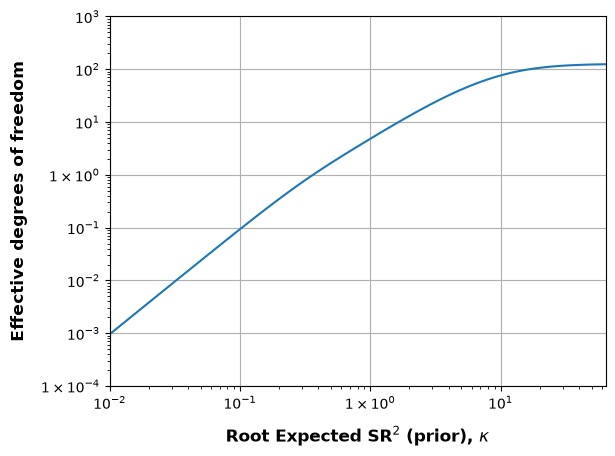

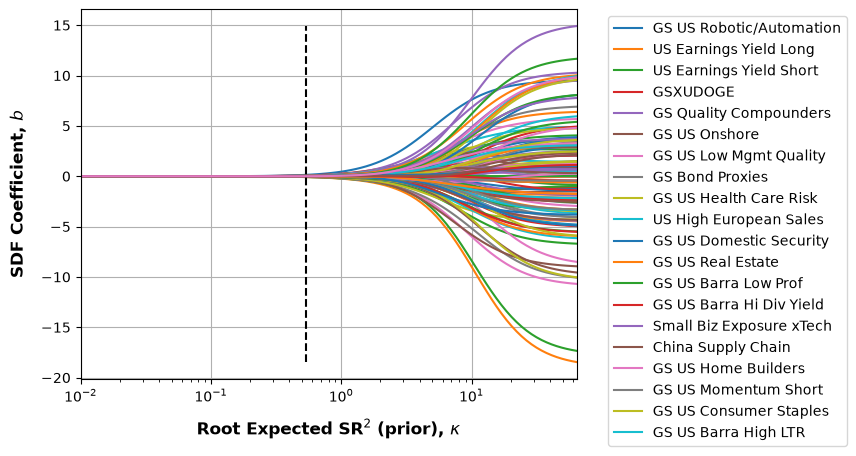

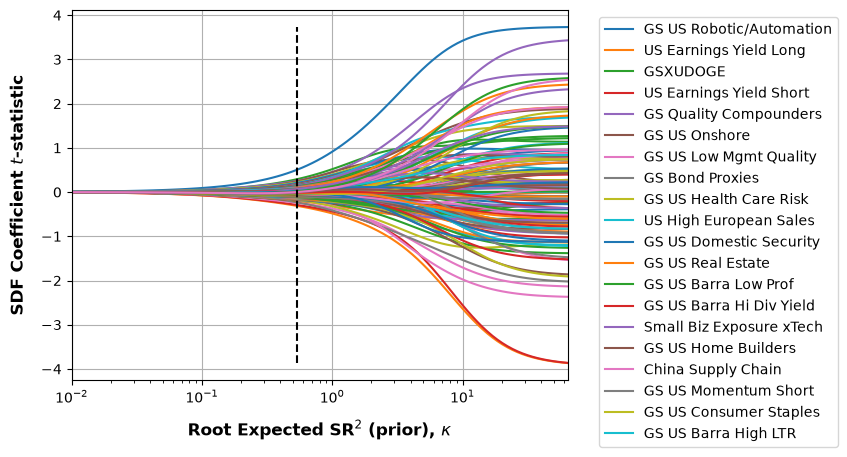

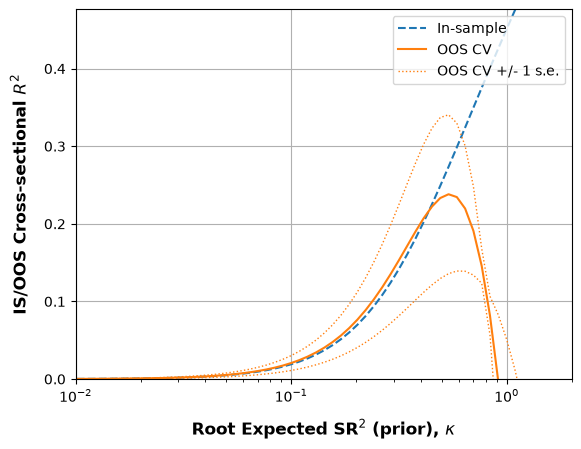

In [32]:

estimates = SCS_L2est(dates, re, market, freq, anomaly_names, parameters={})

In [33]:


def top_bottom_beta_table(estimates, anomaly_names, n=5):
    """
    Extract the top-n highest and lowest optimal SDF beta coefficients (bL2)
    from the estimates dict returned by SCS_L2est, paired with their names.
    """
    bL2 = estimates['bL2']

    df = pd.DataFrame({
        'Portfolio': anomaly_names,
        'beta': bL2
    })

    top5 = df.sort_values('beta', ascending=False).head(n).reset_index(drop=True)
    bottom5 = df.sort_values('beta', ascending=True).head(n).reset_index(drop=True)

    top5.index = [f'Top {i+1}' for i in range(len(top5))]
    bottom5.index = [f'Bottom {i+1}' for i in range(len(bottom5))]

    result = pd.concat([top5, bottom5])
    return result


table = top_bottom_beta_table(estimates, anomaly_names, n=5)


top5 = table.loc[table.index.str.startswith('Top')]
bottom5 = table.loc[table.index.str.startswith('Bottom')]

print("=== LONG signals (highest optimal SDF weight) ===")
for _, row in top5.iterrows():
    print(f"  {row['Portfolio']:<30} beta = {row['beta']:+.4f}")

print()
print("=== SHORT signals (lowest optimal SDF weight) ===")
for _, row in bottom5.iterrows():
    print(f"  {row['Portfolio']:<30} beta = {row['beta']:+.4f}")

=== LONG signals (highest optimal SDF weight) ===
  GS US Robotic/Automation       beta = +0.1366
  GSXUDOGE                       beta = +0.0789
  GS Quality Compounders         beta = +0.0692
  GS US Onshore                  beta = +0.0667
  GS US Health Care Risk         beta = +0.0597

=== SHORT signals (lowest optimal SDF weight) ===
  US Earnings Yield Long         beta = -0.0846
  US Earnings Yield Short        beta = -0.0789
  GS US Low Mgmt Quality         beta = -0.0657
  GS Bond Proxies                beta = -0.0627
  GS US Real Estate              beta = -0.0529


Annualized Sharpe ratio: 0.014


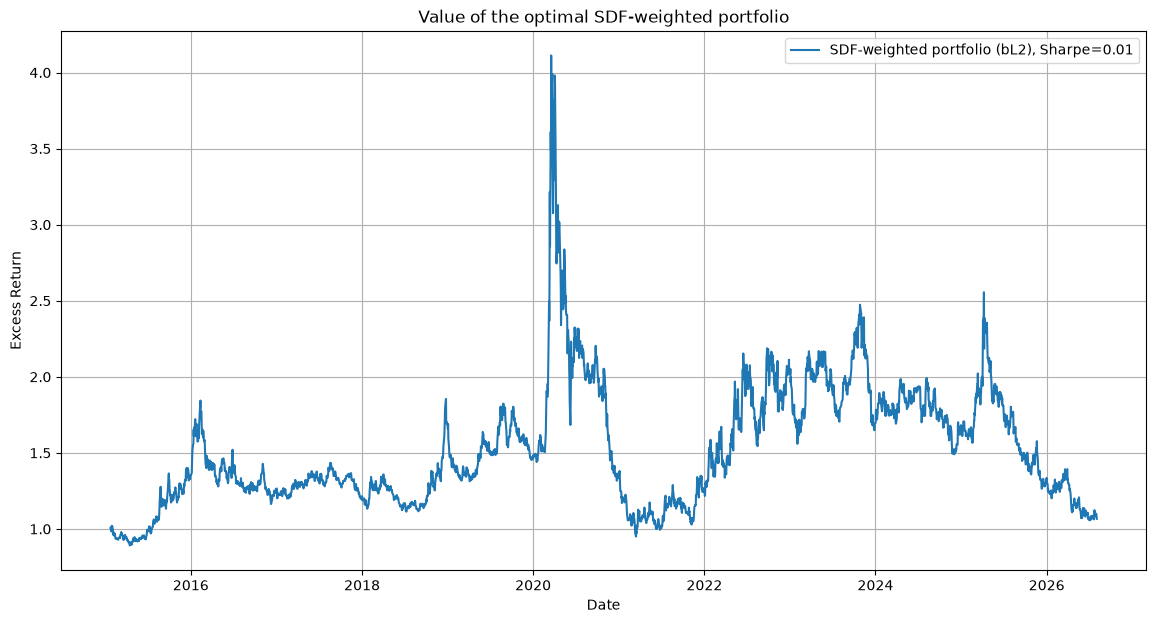

In [34]:
bL2 = estimates['bL2']

# Weighted portfolio return each day = anomaly returns × optimal SDF weights
portfolio_returns = re.dot(bL2)

# Portfolio value, starting at 1
portfolio_value = np.exp(portfolio_returns.cumsum())

# --- Sharpe ratio (volatility-adjusted return) ---
freq = 252 # observations per year, e.g. 252 for daily
sharpe_ratio = portfolio_returns.mean() / portfolio_returns.std() * np.sqrt(freq)
print(f"Annualized Sharpe ratio: {sharpe_ratio:.3f}")

plt.figure(figsize=(14, 7))
plt.plot(dates, portfolio_value, label=f'SDF-weighted portfolio (bL2), Sharpe={sharpe_ratio:.2f}')
plt.xlabel('Date')
plt.ylabel('Excess Return')
plt.title('Value of the optimal SDF-weighted portfolio')
plt.grid(True)
plt.legend()
plt.show()